# Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split




In [2]:
import sys
sys.path.append('..')
from src.evaluation import evaluate

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')
print(df.shape)
df.head()



(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Exploratory data analysis

## 1. Dataset structure 

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## 2. Target distribution 

In [6]:

df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [7]:
cat_cols = df.select_dtypes(include='object').columns

/var/folders/dt/v_rjt_mx4k1g8dyxbm2gw8140000gn/T/ipykernel_13292/2176772794.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


## 3. Masked missing values ('unknown') in categorical columns


In [8]:
for col in cat_cols:
    share = (df[col] == 'unknown').mean()
    if share > 0:
        print(f'{col}: {share:.3f}')

job: 0.008
marital: 0.002
education: 0.042
default: 0.209
housing: 0.024
loan: 0.024


## 4. Temporal structure of the data




<Axes: >

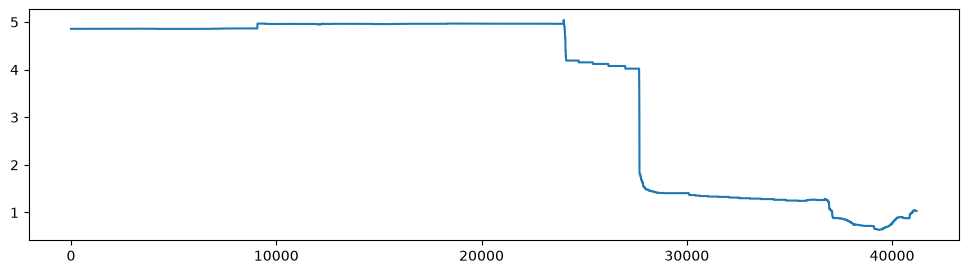

In [9]:
df['euribor3m'].plot(figsize=(12, 3))

## 5. Conversion over time


<Axes: >

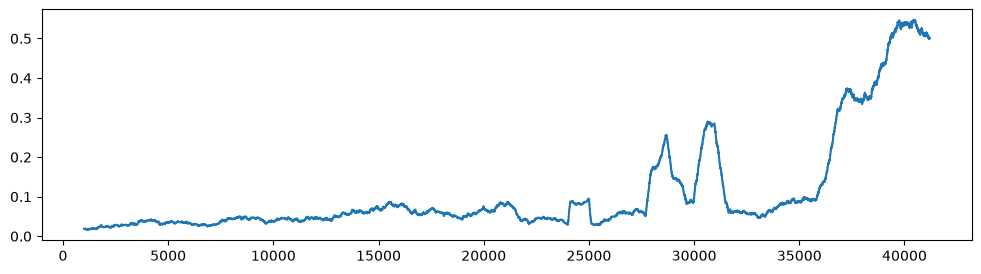

In [10]:
df['y_bin'] = (df['y'] == 'yes').astype(int)
df['y_bin'].rolling(1000).mean().plot(figsize=(12, 3))

## 6. Monthly conversion rate


In [11]:
df.groupby('month')['y_bin'].agg(['mean', 'count'])


,mean,count
month,,
apr,0.204787,2632
aug,0.106021,6178
dec,0.489011,182
jul,0.090466,7174
jun,0.105115,5318
mar,0.505495,546
may,0.064347,13769
nov,0.101439,4101
oct,0.438719,718


## 7. Previous contact history


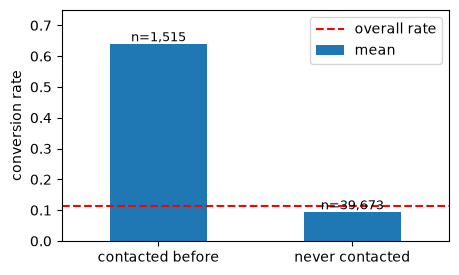

In [12]:
# Conversion: previously contacted vs not.
never_contacted = (df['pdays'] == 999)

stats = df.groupby(never_contacted)['y_bin'].agg(['mean', 'count'])
stats.index = ['contacted before', 'never contacted']

ax = stats['mean'].plot(kind='bar', figsize=(5, 3), rot=0)

for i, (m, n) in enumerate(zip(stats['mean'], stats['count'])):
    ax.text(i, m + 0.01, f'n={n:,}', ha='center', fontsize=9)

plt.axhline(df['y_bin'].mean(), color='red', linestyle='--', label='overall rate')
plt.ylabel('conversion rate')
plt.ylim(0, 0.75)
plt.legend()
plt.show()



In [13]:
# 999 is a sentinel, not a duration. Split the column into a flag and a real distance.

df['was_contacted_before'] = (df['pdays'] != 999).astype(int)
df['pdays_clean'] = df['pdays'].where(df['pdays'] != 999, -1)

## 8. Outcome of the previous campaign


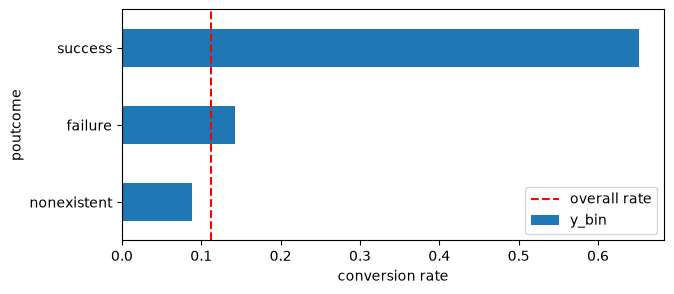

In [14]:
conv = df.groupby('poutcome')['y_bin'].mean().sort_values()

conv.plot(kind='barh', figsize=(7, 3))
plt.axvline(df['y_bin'].mean(), color='red', linestyle='--', label='overall rate')
plt.xlabel('conversion rate')
plt.legend()
plt.show()

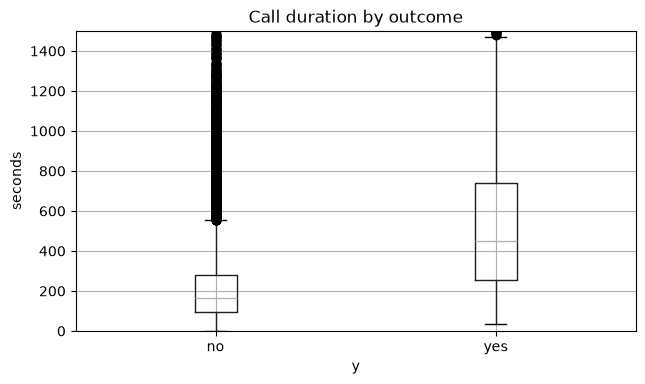

In [15]:
# Duration distribution by outcome.

df.boxplot(column='duration', by='y', figsize=(7, 4))
plt.ylim(0, 1500)
plt.suptitle('')
plt.title('Call duration by outcome')
plt.ylabel('seconds')
plt.show()



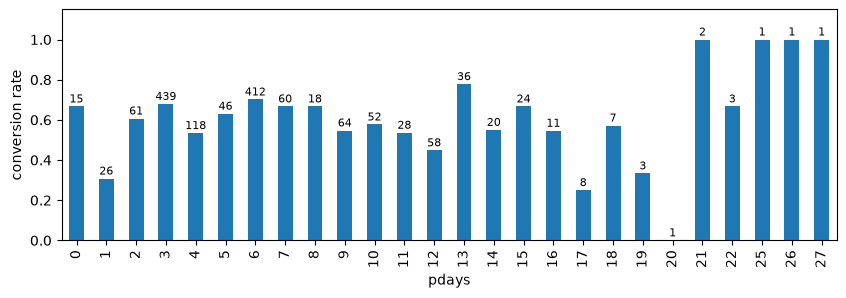

In [16]:
# Conversion by days since previous contact.

contacted = df[df['pdays'] != 999]
stats = contacted.groupby('pdays')['y_bin'].agg(['mean', 'count'])

ax = stats['mean'].plot(kind='bar', figsize=(10, 3))

for i, n in enumerate(stats['count']):
    ax.text(i, stats['mean'].iloc[i] + 0.02, str(n), ha='center', fontsize=8)

plt.ylabel('conversion rate')
plt.ylim(0, 1.15)
plt.show()

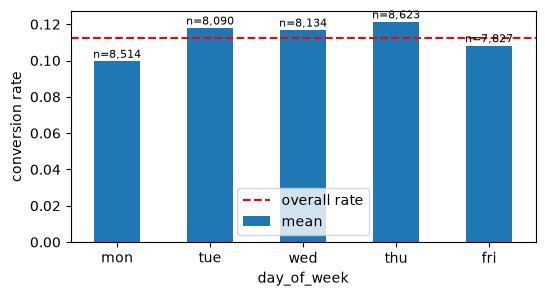

In [17]:
# Conversion by day of week.

order = ['mon', 'tue', 'wed', 'thu', 'fri']
stats = df.groupby('day_of_week')['y_bin'].agg(['mean', 'count']).reindex(order)

ax = stats['mean'].plot(kind='bar', figsize=(6, 3), rot=0)

for i, (m, n) in enumerate(zip(stats['mean'], stats['count'])):
    ax.text(i, m + 0.002, f'n={n:,}', ha='center', fontsize=8)

plt.axhline(df['y_bin'].mean(), color='red', linestyle='--', label='overall rate')
plt.ylabel('conversion rate')
plt.legend()
plt.show()

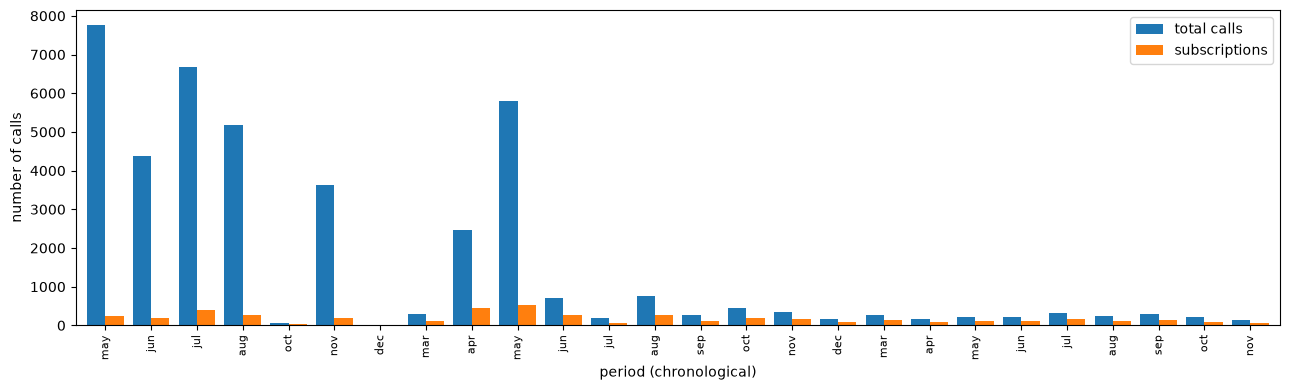

In [18]:
# Reconstruct calendar periods: rows are chronological, so each change
# in `month` marks a new period (May 2008 - Nov 2010).

period = (df['month'] != df['month'].shift()).cumsum()

stats = df.groupby(period).agg(
    month=('month', 'first'),
    calls=('y_bin', 'size'),
    successes=('y_bin', 'sum'),
)

ax = stats[['calls', 'successes']].plot(kind='bar', figsize=(13, 4), width=0.8)
ax.set_xticklabels(stats['month'], rotation=90, fontsize=8)
plt.ylabel('number of calls')
plt.xlabel('period (chronological)')
plt.legend(['total calls', 'subscriptions'])
plt.tight_layout()
plt.show()

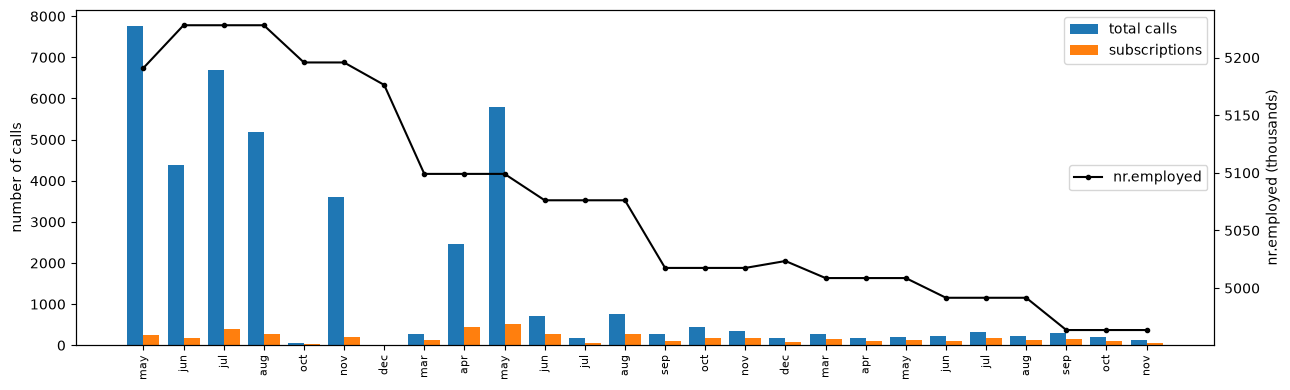

In [19]:
# Calls, subscriptions and employment level per reconstructed period.

period = (df['month'] != df['month'].shift()).cumsum()

stats = df.groupby(period).agg(
    month=('month', 'first'),
    calls=('y_bin', 'size'),
    successes=('y_bin', 'sum'),
    employed=('nr.employed', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(13, 4))

x = range(len(stats))
ax1.bar([i - 0.2 for i in x], stats['calls'], width=0.4, label='total calls')
ax1.bar([i + 0.2 for i in x], stats['successes'], width=0.4, label='subscriptions')
ax1.set_ylabel('number of calls')
ax1.set_xticks(list(x))
ax1.set_xticklabels(stats['month'], rotation=90, fontsize=8)
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(x, stats['employed'], color='black', marker='o', markersize=3,
         linewidth=1.5, label='nr.employed')
ax2.set_ylabel('nr.employed (thousands)')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

In [20]:
# Rows before and after the campaign-mode change (June 2009 = period 11).

before = (period <= 10).sum()
after = (period > 10).sum()

print(f"periods 1-10  (may 2008 - may 2009): {before:,} rows, "
      f"conversion {df.loc[period <= 10, 'y_bin'].mean():.4f}")
print(f"periods 11-26 (jun 2009 - nov 2010): {after:,} rows, "
      f"conversion {df.loc[period > 10, 'y_bin'].mean():.4f}")

periods 1-10  (may 2008 - may 2009): 36,224 rows, conversion 0.0671
periods 11-26 (jun 2009 - nov 2010): 4,964 rows, conversion 0.4450


## **Why a random split rather than a temporal one?**

The reconstructed monthly timeline shows a radical change in call-centre behaviour
rather than in client behaviour. Through May 2009 the bank dialled thousands of clients
per month at 6.7% conversion. From June 2009 onwards volumes collapsed to a few hundred
per month while conversion rose to 44.5% — the same clients were not becoming more
willing; the bank simply stopped calling everyone.

The two regimes are badly unbalanced in the data. The first covers 13 months and 36,214
rows; the second covers 18 months but only 4,962 rows, because so few calls were made.
The newer regime is just 12% of the dataset.

This makes a temporal split unusable. A chronological 70/15/15 would put the mass-
dialling regime almost entirely in training and the selective regime almost entirely in
validation and test. The model would be trained on one operating mode and evaluated on
another it had never seen. That measures extrapolation to an unseen regime, not ranking
quality — and since the PR-AUC baseline differs 6.6× between the two blocks, the train
and test figures would not even be comparable.

A stratified random split keeps both regimes present in all three parts. The cost is
that temporally adjacent rows share macroeconomic context, so the reported figures are
likely optimistic relative to a temporal split on homogeneous data.

## 9. Correlations among numeric features


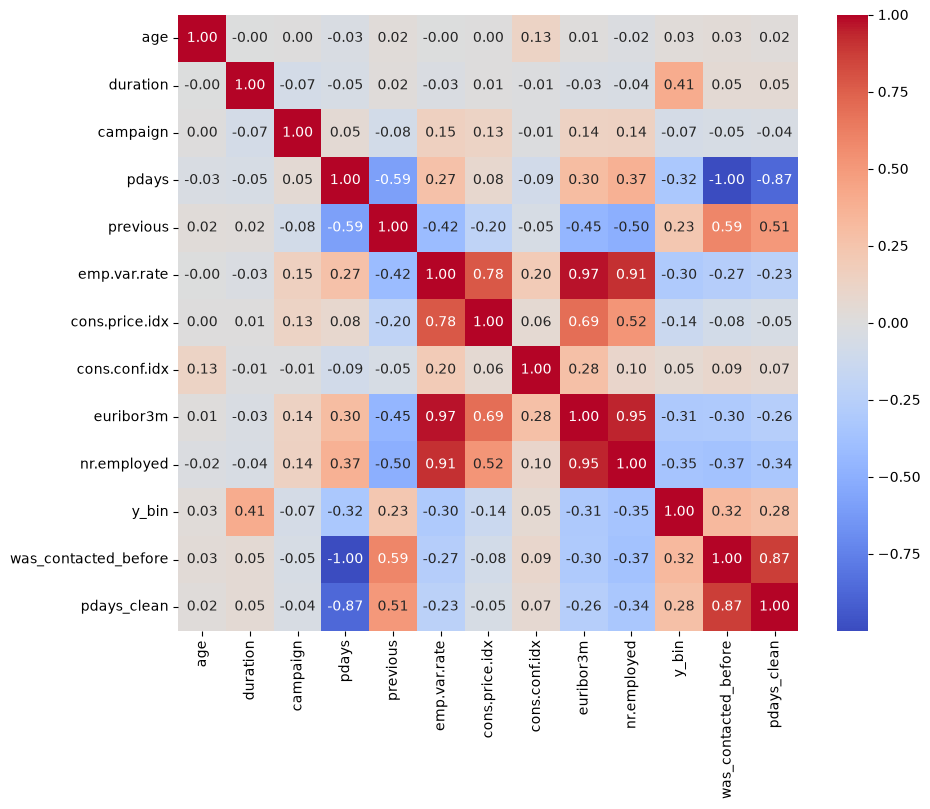

In [21]:
num_cols = df.select_dtypes(include='number').columns
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

## 11. Age


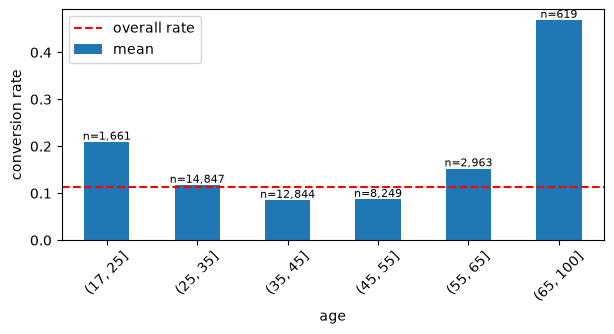

In [22]:
# Conversion by age bin.

bins = [17, 25, 35, 45, 55, 65, 100]
age_bin = pd.cut(df['age'], bins=bins)

stats = df.groupby(age_bin, observed=True)['y_bin'].agg(['mean', 'count'])

ax = stats['mean'].plot(kind='bar', figsize=(7, 3), rot=45)

for i, (m, n) in enumerate(zip(stats['mean'], stats['count'])):
    ax.text(i, m + 0.005, f'n={n:,}', ha='center', fontsize=8)

plt.axhline(df['y_bin'].mean(), color='red', linestyle='--', label='overall rate')
plt.ylabel('conversion rate')
plt.legend()
plt.show()

## 12. Conversion for categorical features

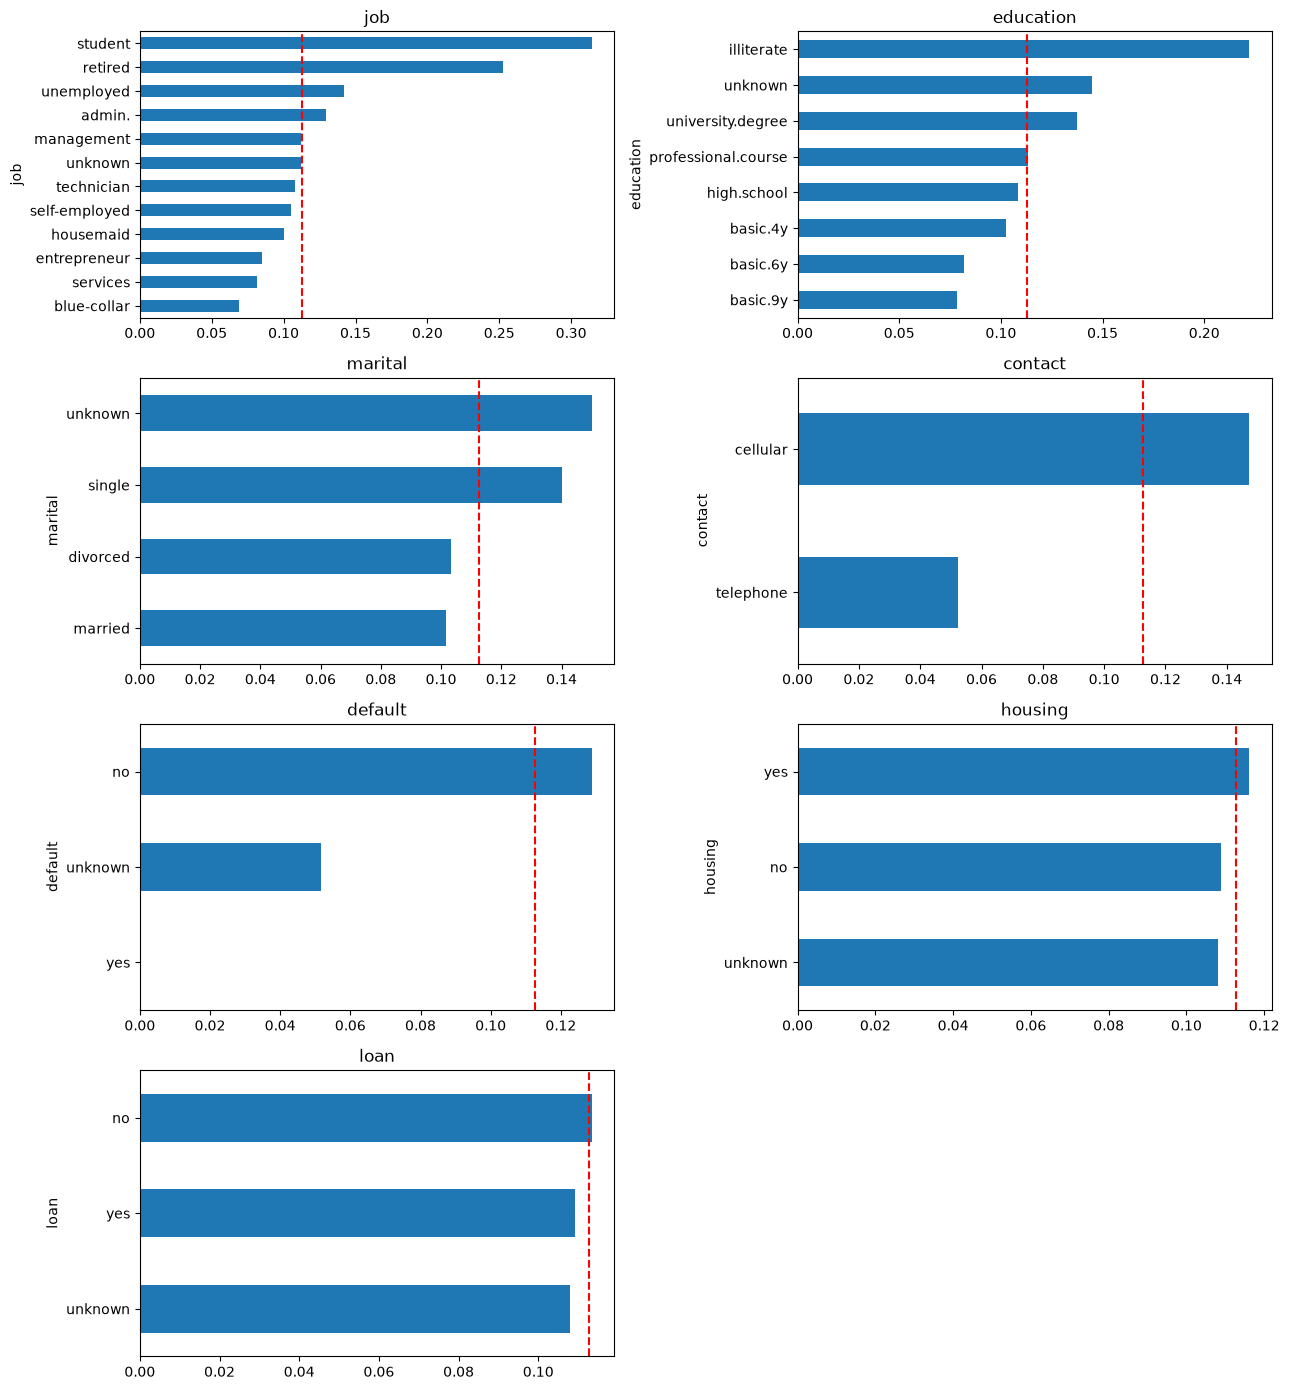

In [23]:
# Conversion by category, for all remaining categorical features.

cols = ['job', 'education', 'marital', 'contact', 'default', 'housing', 'loan']

fig, axes = plt.subplots(4, 2, figsize=(13, 14))

for ax, col in zip(axes.flat, cols):
    df.groupby(col)['y_bin'].mean().sort_values().plot(kind='barh', ax=ax)
    ax.axvline(df['y_bin'].mean(), color='red', linestyle='--')
    ax.set_title(col)

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

## 13. Outliers in numeric features


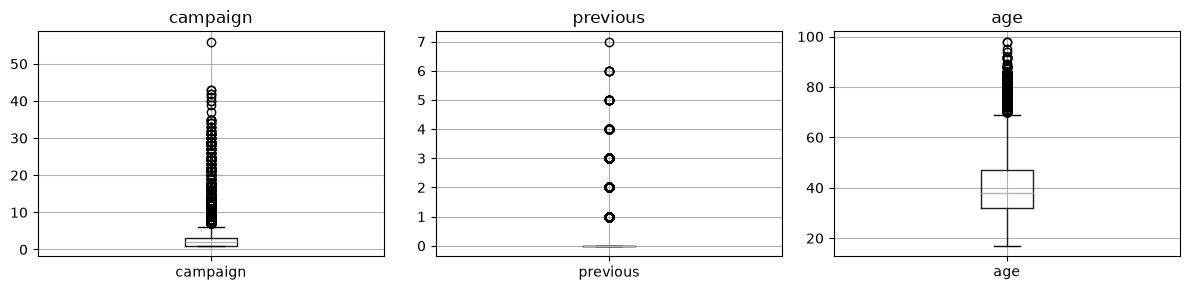

In [24]:
# Distribution of the three features with long tails.

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, col in zip(axes, ['campaign', 'previous', 'age']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [25]:
print(df[['campaign', 'previous', 'age']].describe(percentiles=[.5, .9, .99]))

           campaign      previous          age
count  41188.000000  41188.000000  41188.00000
mean       2.567593      0.172963     40.02406
std        2.770014      0.494901     10.42125
min        1.000000      0.000000     17.00000
50%        2.000000      0.000000     38.00000
90%        5.000000      1.000000     55.00000
99%       14.000000      2.000000     71.00000
max       56.000000      7.000000     98.00000


In [26]:
print(f"exact duplicates: {df.duplicated().sum()}")

exact duplicates: 12


In [27]:
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(24)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_bin,was_contacted_before,pdays_clean
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no,0,0,-1
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no,0,0,-1
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,0,0,-1
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,0,0,-1
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,0,0,-1
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,0,0,-1
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0,0,-1
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0,0,-1
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no,0,0,-1
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no,0,0,-1


In [28]:
# 12 exact duplicates, including identical call durations — a loading artefact
# rather than distinct clients. Remove.

df = df.drop_duplicates()
print(df.shape)

(41176, 24)


# Preprocessing


## 1. Split 

In [29]:
train, temp = train_test_split(df, test_size=0.30, stratify=df['y_bin'], random_state=42)

In [30]:
val, test = train_test_split(temp, test_size=0.50, stratify=temp['y_bin'], random_state=42)

In [31]:
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f"{name}: {len(part):,} rows, conversion {part['y_bin'].mean():.4f}")


train: 28,823 rows, conversion 0.1127
val: 6,176 rows, conversion 0.1127
test: 6,177 rows, conversion 0.1127


## 2. Separate features from target. 


In [32]:
DROP = ['duration', 'y', 'y_bin', 'pdays', 'pdays_clean']

X_train, y_train = train.drop(columns=DROP), train['y_bin']
X_val, y_val = val.drop(columns=DROP), val['y_bin']
X_test, y_test = test.drop(columns=DROP), test['y_bin']
print(X_train.shape, X_val.shape, X_test.shape)

(28823, 19) (6176, 19) (6177, 19)


In [33]:
X_train


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before
27506,57,admin.,married,high.school,no,yes,no,cellular,nov,fri,2,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
20991,44,blue-collar,married,basic.6y,unknown,no,no,cellular,aug,thu,1,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,0
34380,31,blue-collar,single,high.school,no,no,no,cellular,may,thu,1,1,failure,-1.8,92.893,-46.2,1.266,5099.1,0
17259,53,retired,married,professional.course,no,no,no,cellular,jul,fri,2,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
15329,31,self-employed,single,university.degree,no,yes,no,cellular,jul,fri,2,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6971,32,management,married,university.degree,no,yes,no,telephone,may,thu,1,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
8970,33,admin.,married,university.degree,no,unknown,unknown,telephone,jun,thu,1,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
33752,30,entrepreneur,married,university.degree,no,no,no,cellular,may,wed,1,0,nonexistent,-1.8,92.893,-46.2,1.281,5099.1,0
18503,34,technician,married,professional.course,unknown,no,no,cellular,jul,thu,1,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0


In [34]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

print(f"categorical ({len(cat_cols)}): {cat_cols}")
print(f"numeric ({len(num_cols)}): {num_cols}")

categorical (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
numeric (9): ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before']


/var/folders/dt/v_rjt_mx4k1g8dyxbm2gw8140000gn/T/ipykernel_13292/4104197311.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


## 3. Preprocessing pipeline for tree models

Trees split on thresholds, so scaling and skew correction have no effect. The only
required step is turning categorical strings into numbers.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
tree_prep = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', 'passthrough', num_cols),
])

X_train_tree = tree_prep.fit_transform(X_train)
X_val_tree = tree_prep.transform(X_val)

print(X_train_tree.shape)



(28823, 19)


## 4. Decision tree

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
tree = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
tree.fit(X_train_tree, y_train)

train_proba = tree.predict_proba(X_train_tree)[:, 1]
val_proba = tree.predict_proba(X_val_tree)[:, 1]

print(f"PR-AUC  train: {average_precision_score(y_train, train_proba):.4f}")
print(f"PR-AUC  val:   {average_precision_score(y_val, val_proba):.4f}")
print(f"ROC-AUC train: {roc_auc_score(y_train, train_proba):.4f}")
print(f"ROC-AUC val:   {roc_auc_score(y_val, val_proba):.4f}")
print(f"baseline:      {y_train.mean():.4f}")

PR-AUC  train: 0.4229
PR-AUC  val:   0.4231
ROC-AUC train: 0.7819
ROC-AUC val:   0.7803
baseline:      0.1127


In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5-fold CV on the training set only. 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in [3, 5, 6, 7, 8, 10]:
    t = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    scores = cross_val_score(t, X_train_tree, y_train, cv=cv, scoring='average_precision')
    print(f"depth={depth:>2}  PR-AUC {scores.mean():.4f} ± {scores.std():.4f}")

depth= 3  PR-AUC 0.3661 ± 0.0110
depth= 5  PR-AUC 0.4007 ± 0.0129
depth= 6  PR-AUC 0.4134 ± 0.0146
depth= 7  PR-AUC 0.4105 ± 0.0156
depth= 8  PR-AUC 0.4083 ± 0.0154
depth=10  PR-AUC 0.3738 ± 0.0168


In [38]:
tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
tree.fit(X_train_tree, y_train)

tree_result = evaluate(tree, X_train_tree, y_train, X_val_tree, y_val,
                       'Decision Tree', 'max_depth=6, balanced')
pd.Series(tree_result)

model                    Decision Tree
params           max_depth=6, balanced
pr_auc_train                  0.452774
pr_auc_val                    0.431756
pr_auc_gap                    0.021018
roc_auc_train                 0.791554
roc_auc_val                   0.785282
dtype: object

## 5. XGBoost

In [39]:
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(scale_pos_weight=spw, eval_metric='aucpr', random_state=42)
xgb.fit(X_train_tree, y_train)

xgb_result = evaluate(xgb, X_train_tree, y_train, X_val_tree, y_val,
                      'XGBoost', f'defaults, spw={spw:.2f}')
pd.Series(xgb_result)

model                       XGBoost
params           defaults, spw=7.88
pr_auc_train               0.751882
pr_auc_val                  0.41737
pr_auc_gap                 0.334512
roc_auc_train              0.942144
roc_auc_val                0.760595
dtype: object

## 6. Hyperparameter tuning: RandomizedSearchCV

Random sampling from a parameter distribution, scored by 5-fold CV on the training
set. The default XGBoost overfits heavily (gap 0.335), so the search space is built
around regularisation: shallower trees, lower learning rate, subsampling.

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='aucpr',
    random_state=42,
)
xgb_base._estimator_type = "classifier"
param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(2, 8),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 20),
    'gamma': uniform(0, 5),
}

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_tree, y_train)

print(f"best CV PR-AUC: {search.best_score_:.4f}")
print(search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best CV PR-AUC: 0.4675
{'colsample_bytree': np.float64(0.9594216754108317), 'gamma': np.float64(3.0321452982979498), 'learning_rate': np.float64(0.012667144968822599), 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 252, 'subsample': np.float64(0.6020246335384875)}


In [41]:
xgb_rs = search.best_estimator_

xgb_rs_result = evaluate(xgb_rs, X_train_tree, y_train, X_val_tree, y_val,
                         'XGBoost + RandomizedSearch',
                         f'lr=0.013, depth=7, n_est=252, gamma=3.03')
pd.Series(xgb_rs_result)


model                          XGBoost + RandomizedSearch
params           lr=0.013, depth=7, n_est=252, gamma=3.03
pr_auc_train                                     0.556818
pr_auc_val                                       0.472364
pr_auc_gap                                       0.084454
roc_auc_train                                    0.857913
roc_auc_val                                      0.803436
dtype: object

## 7. Hyperparameter tuning: Hyperopt (Bayesian optimisation)

Unlike random sampling, Bayesian optimisation builds a model of the objective
surface and concentrates sampling where improvement is likely. Same search space
and the same CV scheme, so the two methods are directly comparable.


In [42]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import numpy as np

space = {
    'n_estimators': hp.quniform('n_estimators', 100, 600, 1),
    'max_depth': hp.quniform('max_depth', 2, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_weight': hp.quniform('min_child_weight', 1, 20, 1),
    'gamma': hp.uniform('gamma', 0, 5),
}

def objective(params):
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model = XGBClassifier(
        **params,
        scale_pos_weight=spw,
        eval_metric='aucpr',
        random_state=42,
    )
    scores = cross_val_score(model, X_train_tree, y_train,
                             cv=cv, scoring='average_precision', n_jobs=-1)
    return {'loss': -scores.mean(), 'status': STATUS_OK}

trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=50,
            trials=trials, rstate=np.random.default_rng(42))

print(f"best CV PR-AUC: {-min(trials.losses()):.4f}")
print(best)

100%|██████████| 50/50 [01:20<00:00,  1.61s/trial, best loss: -0.4710577396698117] 
best CV PR-AUC: 0.4711
{'colsample_bytree': np.float64(0.6811891112198021), 'gamma': np.float64(3.7936634450050732), 'learning_rate': np.float64(0.02120202145522126), 'max_depth': np.float64(8.0), 'min_child_weight': np.float64(18.0), 'n_estimators': np.float64(353.0), 'subsample': np.float64(0.8970165968892057)}


In [43]:
best_params = {
    'n_estimators': int(best['n_estimators']),
    'max_depth': int(best['max_depth']),
    'min_child_weight': int(best['min_child_weight']),
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
}

xgb_hp = XGBClassifier(**best_params, scale_pos_weight=spw,
                       eval_metric='aucpr', random_state=42)
xgb_hp.fit(X_train_tree, y_train)

xgb_hp_result = evaluate(xgb_hp, X_train_tree, y_train, X_val_tree, y_val,
                         'XGBoost + Hyperopt',
                         'lr=0.021, depth=8, n_est=353, mcw=18')
pd.Series(xgb_hp_result)

model                              XGBoost + Hyperopt
params           lr=0.021, depth=8, n_est=353, mcw=18
pr_auc_train                                 0.574504
pr_auc_val                                   0.473459
pr_auc_gap                                   0.101045
roc_auc_train                                0.886312
roc_auc_val                                  0.802342
dtype: object

Bayesian optimisation (TPE) reached 0.4711 against 0.4675 for random search, at the
same budget of 50 evaluations and comparable runtime. 
The difference is well inside
the CV standard deviation (~0.015), so the two methods are equivalent here.

 The two methods also converged on quite different
parameter sets while producing the same score, which indicates a flat objective
surface rather than a sharp optimum.

## 8. Preprocessing pipeline for linear models and kNN

Unlike trees, linear models and kNN need one-hot encoding, tail compression and
scaling. `emp.var.rate` and `nr.employed` are dropped, keeping `euribor3m` as the single
macroeconomic feature. The three correlate at 0.91–0.97 and encode the same
macroeconomic moment; `euribor3m` is kept because it is the most directly
interpretable of the three.

In [44]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# emp.var.rate and nr.employed correlate 0.91-0.97 with euribor3m.
DROP_MACRO = ['emp.var.rate', 'nr.employed']
SKEWED = ['campaign', 'previous']

num_linear = [c for c in num_cols if c not in DROP_MACRO]
num_plain = [c for c in num_linear if c not in SKEWED]

linear_prep = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('skewed', Pipeline([
        ('log', FunctionTransformer(np.log1p)),
        ('scale', StandardScaler()),
    ]), SKEWED),
    ('num', StandardScaler(), num_plain),
])

X_train_lin = linear_prep.fit_transform(X_train)
X_val_lin = linear_prep.transform(X_val)

print(X_train_lin.shape)

(28823, 60)


## 9. Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)
logreg.fit(X_train_lin, y_train)

logreg_result = evaluate(logreg, X_train_lin, y_train, X_val_lin, y_val,
                         'Logistic Regression', 'balanced, L2, C=1.0')
pd.Series(logreg_result)

model            Logistic Regression
params           balanced, L2, C=1.0
pr_auc_train                0.438867
pr_auc_val                    0.4374
pr_auc_gap                  0.001467
roc_auc_train               0.790227
roc_auc_val                 0.791751
dtype: object

## 10. kNN model

In [46]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=25, n_jobs=-1)
knn.fit(X_train_lin, y_train)

knn_result = evaluate(knn, X_train_lin, y_train, X_val_lin, y_val,
                      'kNN', 'k=25, euclidean')
pd.Series(knn_result)

model                        kNN
params           k=25, euclidean
pr_auc_train            0.476277
pr_auc_val              0.430523
pr_auc_gap              0.045755
roc_auc_train           0.848062
roc_auc_val             0.772961
dtype: object

## 11. Feature importance
Gain-based importance from the tuned XGBoost: how much each feature reduced the loss
across all splits where it was used.

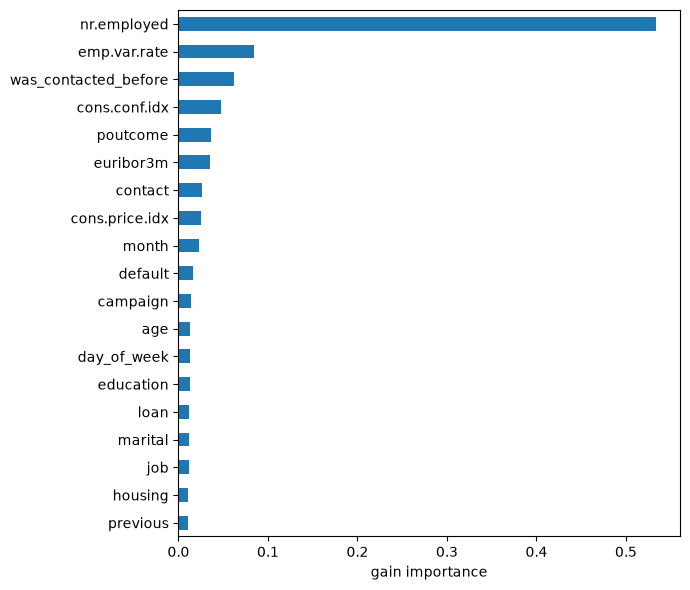

In [47]:
importances = pd.Series(
    xgb_hp.feature_importances_,
    index=cat_cols + num_cols
).sort_values()

importances.plot(kind='barh', figsize=(7, 6))
plt.xlabel('gain importance')
plt.tight_layout()
plt.show()

Unfortunately, employment does not help answer the business question. The model is
learning *when* conversion was higher rather than *which* client is inclined to
subscribe. It is therefore worth testing the hypothesis with the macroeconomic
features removed.

In [68]:
results = pd.DataFrame([
    tree_result,
    xgb_result,
    xgb_rs_result,
    xgb_hp_result,
    logreg_result,
    knn_result,
    nomacro_result,
]).sort_values('pr_auc_val', ascending=False) .reset_index(drop=True)

comments = {
    'XGBoost + Hyperopt': 'Best on validation. Selected as final model.',
    'XGBoost + RandomizedSearch': 'Equivalent to Hyperopt within CV noise (0.4675 vs 0.4711). Smaller gap.',
    'Logistic Regression': 'Near-zero gap. Strong for its simplicity — one-hot recovers the non-monotonic age effect through job categories.',
    'Decision Tree': 'Interpretable baseline. Depth beyond 6 degrades validation.',
    'kNN': 'On par with the tree despite no class weighting. Slow at inference.',
    'XGBoost': 'Defaults overfit badly (gap 0.34) and lose to a depth-6 tree. Shows what tuning is for.',
    'XGBoost, no macro': 'Diagnostic, not a candidate. Isolates client-level signal: −10% PR-AUC.',
}

results['comment'] = results['model'].map(comments)
results.round(4)
print(results.round(4).to_markdown(index=False))


| model                      | params                                   |   pr_auc_train |   pr_auc_val |   pr_auc_gap |   roc_auc_train |   roc_auc_val | comment                                                                                                          |
|:---------------------------|:-----------------------------------------|---------------:|-------------:|-------------:|----------------:|--------------:|:-----------------------------------------------------------------------------------------------------------------|
| XGBoost + Hyperopt         | lr=0.021, depth=8, n_est=353, mcw=18     |         0.5745 |       0.4735 |       0.101  |          0.8863 |        0.8023 | Best on validation. Selected as final model.                                                                     |
| XGBoost + RandomizedSearch | lr=0.013, depth=7, n_est=252, gamma=3.03 |         0.5568 |       0.4724 |       0.0845 |          0.8579 |        0.8034 | Equivalent to Hyperopt within CV no

## 12. How much of the model's quality is usable for targeting?

Macroeconomic features account for ~72% of gain importance, with `nr.employed` alone at 0.53. The relationship is real — falling rates during 2008–2010 made deposits more attractive but these features describe *when* a call was made, not *who* was called.
`nr.employed` is a quarterly figure, identical for every client scored on the same day, so it cannot rank anyone.

Retraining without the macro block isolates client-level signal. The resulting PR-AUC is the honest estimate of how well the model ranks clients at a fixed point in time, which is the situation the call centre faces.

In [48]:

macro = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
keep = [c for c in (cat_cols + num_cols) if c not in macro]

X_train_nomacro = pd.DataFrame(X_train_tree, columns=cat_cols + num_cols)[keep]
X_val_nomacro = pd.DataFrame(X_val_tree, columns=cat_cols + num_cols)[keep]

xgb_nomacro = XGBClassifier(**best_params, scale_pos_weight=spw,
                            eval_metric='aucpr', random_state=42)
xgb_nomacro.fit(X_train_nomacro, y_train)

nomacro_result = evaluate(xgb_nomacro, X_train_nomacro, y_train,
                          X_val_nomacro, y_val,
                          'XGBoost, no macro', 'same params, macro dropped')
pd.Series(nomacro_result)

model                     XGBoost, no macro
params           same params, macro dropped
pr_auc_train                       0.511469
pr_auc_val                          0.42541
pr_auc_gap                         0.086059
roc_auc_train                      0.851923
roc_auc_val                        0.771809
dtype: object

Removing the macro block costs 0.048 PR-AUC (0.4735 → 0.4254), a 10% drop, despite those features carrying 72% of gain importance.



Client attributes and contact history carry enough signal on their own — 0.4254 is still 3.8× the 0.1127 baseline and on par with the decision tree and logistic regression. The model ranks clients usefully within a fixed point in time; the macro block adds a period-level adjustment on top.

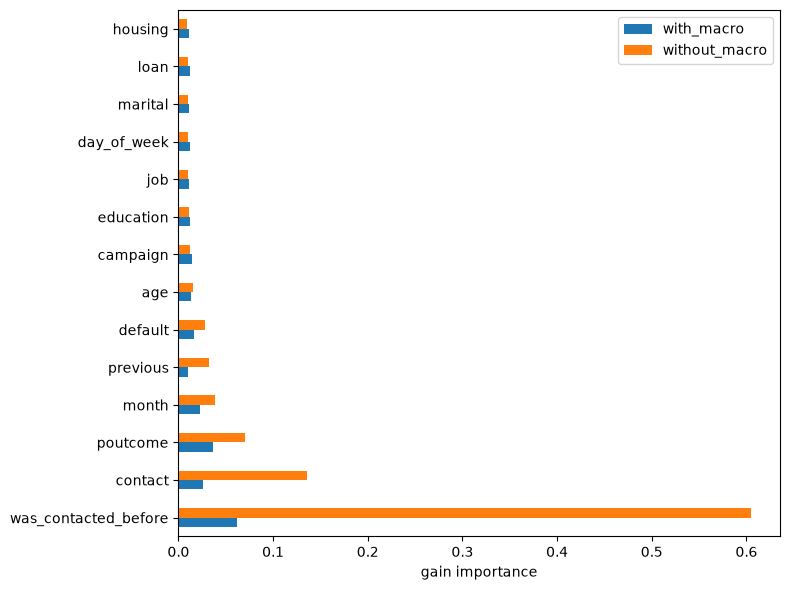

In [49]:
imp_full = pd.Series(xgb_hp.feature_importances_, index=cat_cols + num_cols)
imp_nomacro = pd.Series(xgb_nomacro.feature_importances_, index=keep)

comparison = pd.DataFrame({
    'with_macro': imp_full[keep],
    'without_macro': imp_nomacro,
}).sort_values('without_macro', ascending=False)

comparison.plot(kind='barh', figsize=(8, 6))
plt.xlabel('gain importance')
plt.tight_layout()
plt.show()


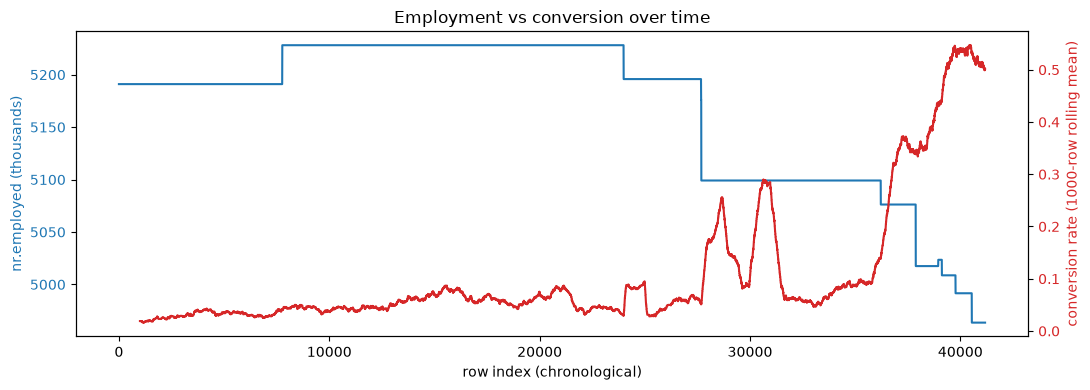

In [50]:
# Employment level and conversion rate over the campaign timeline.

fig, ax1 = plt.subplots(figsize=(11, 4))

ax1.plot(df['nr.employed'].values, color='tab:blue', label='nr.employed')
ax1.set_ylabel('nr.employed (thousands)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xlabel('row index (chronological)')

ax2 = ax1.twinx()
ax2.plot(df['y_bin'].rolling(1000).mean().values, color='tab:red', label='conversion')
ax2.set_ylabel('conversion rate (1000-row rolling mean)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Employment vs conversion over time')
plt.tight_layout()
plt.show()

## 13. SHAP analysis ащк XGB with macro

Gain importance ranks features by how much they reduced loss, but says nothing about
direction. SHAP decomposes each individual prediction into per-feature contributions,
showing both magnitude and sign.

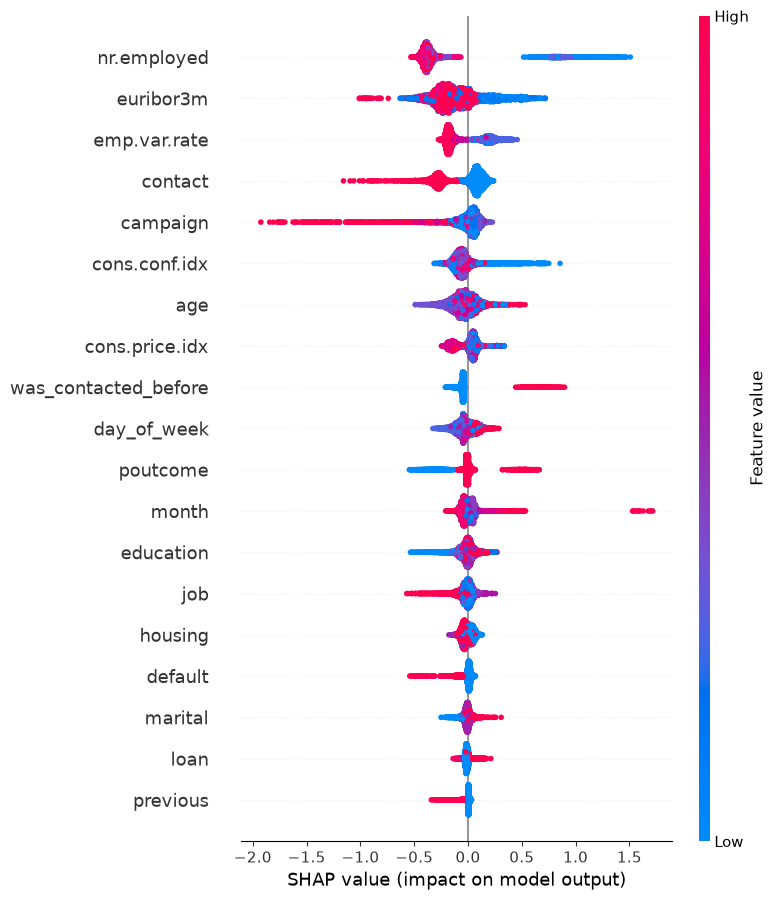

In [51]:
import shap

explainer = shap.TreeExplainer(xgb_hp)
shap_values = explainer.shap_values(X_val_tree)

shap.summary_plot(shap_values, X_val_tree, feature_names=cat_cols + num_cols)

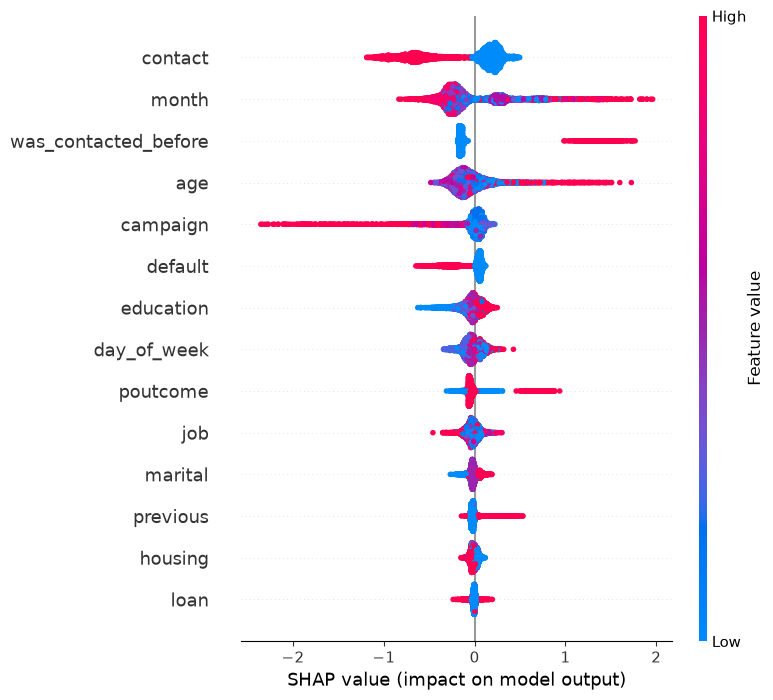

In [52]:
# SHAP for the model without macroeconomic features.

explainer_nm = shap.TreeExplainer(xgb_nomacro)
shap_values_nm = explainer_nm.shap_values(X_val_nomacro)

shap.summary_plot(shap_values_nm, X_val_nomacro, feature_names=keep)

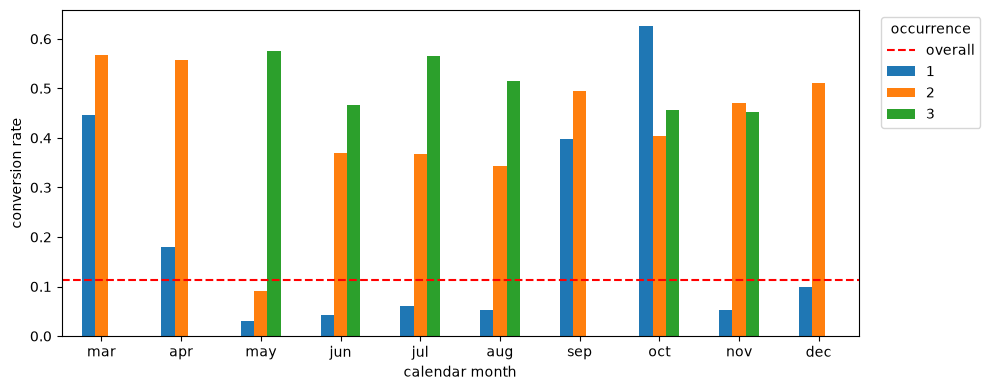

In [54]:
# Same calendar month across years: seasonality or period marker?

stats = df.groupby(period).agg(
    month=('month', 'first'),
    calls=('y_bin', 'size'),
    conversion=('y_bin', 'mean'),
).reset_index(drop=True)

stats['occurrence'] = stats.groupby('month').cumcount() + 1

order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
pivot = stats.pivot_table(index='month', columns='occurrence',
                          values='conversion').reindex(order)

ax = pivot.plot(kind='bar', figsize=(10, 4), rot=0)
plt.axhline(df['y_bin'].mean(), color='red', linestyle='--', label='overall')
plt.ylabel('conversion rate')
plt.xlabel('calendar month')
plt.legend(title='occurrence', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 14. Error analysis 

Where does the model fail, and is there structure in those failures? False negatives
matter most: a missed subscriber is lost revenue, while a wasted call costs a few
minutes.

In [ ]:
# Predictions at the default threshold, for error inspection. (with macro)

val_proba = xgb_hp.predict_proba(X_val_tree)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

errors = X_val.copy()
errors['y_true'] = y_val.values
errors['proba'] = val_proba
errors['pred'] = val_pred

errors['type'] = 'TN'
errors.loc[(errors.y_true == 1) & (errors.pred == 1), 'type'] = 'TP'
errors.loc[(errors.y_true == 1) & (errors.pred == 0), 'type'] = 'FN'
errors.loc[(errors.y_true == 0) & (errors.pred == 1), 'type'] = 'FP'

print(errors['type'].value_counts())

type
TN    4752
FP     728
TP     449
FN     247
Name: count, dtype: int64


In [56]:
# What separates missed subscribers (FN) from caught ones (TP)?

comparison = errors[errors.y_true == 1].groupby('type').agg(
    n=('proba', 'size'),
    mean_proba=('proba', 'mean'),
    age=('age', 'mean'),
    campaign=('campaign', 'mean'),
    contacted_before=('was_contacted_before', 'mean'),
    euribor=('euribor3m', 'mean'),
)
comparison.T

type,FN,TP
n,247.000000,449.000000
mean_proba,0.297761,0.811384
age,39.072874,42.997773
campaign,2.526316,1.712695
contacted_before,0.000000,0.311804
euribor,3.901462,1.087635


In [57]:
# Error analysis for the no-macro model.

val_proba_nm = xgb_nomacro.predict_proba(X_val_nomacro)[:, 1]
val_pred_nm = (val_proba_nm >= 0.5).astype(int)

errors_nm = X_val.copy()
errors_nm['y_true'] = y_val.values
errors_nm['proba'] = val_proba_nm
errors_nm['pred'] = val_pred_nm

errors_nm['type'] = 'TN'
errors_nm.loc[(errors_nm.y_true == 1) & (errors_nm.pred == 1), 'type'] = 'TP'
errors_nm.loc[(errors_nm.y_true == 1) & (errors_nm.pred == 0), 'type'] = 'FN'
errors_nm.loc[(errors_nm.y_true == 0) & (errors_nm.pred == 1), 'type'] = 'FP'

print(errors_nm['type'].value_counts())

type
TN    4684
FP     796
TP     404
FN     292
Name: count, dtype: int64


In [58]:
comparison_nm = errors_nm[errors_nm.y_true == 1].groupby('type').agg(
    n=('proba', 'size'),
    mean_proba=('proba', 'mean'),
    age=('age', 'mean'),
    campaign=('campaign', 'mean'),
    contacted_before=('was_contacted_before', 'mean'),
    euribor=('euribor3m', 'mean'),
)
comparison_nm.T

type,FN,TP
n,292.000000,404.000000
mean_proba,0.338519,0.794209
age,39.297945,43.272277
campaign,2.462329,1.668317
contacted_before,0.000000,0.346535
euribor,3.289017,1.216871


Error analysis points at the same failure mode in both model variants.

**All missed subscribers are first-contact clients.** In both models, `was_contacted_before`
is exactly 0.00 across every false negative, against 0.31–0.35 among caught ones. The
model handles clients with contact history almost perfectly and fails on everyone else.
For that segment the dataset offers only demographics — account balance, tenure and
prior product holdings would be the highest-value additions.

**Errors concentrate in the mass-dialling regime.** Mean `euribor3m` is 3.90 among false
negatives versus 1.09 among true positives. Removing the macro block barely changes this
(3.29 vs 1.22): the model reconstructs the period through `month`, which rose from 12th
to 2nd in SHAP importance. Dropping macro features reroutes the temporal signal rather
than removing it. The structural fix is separate models per campaign regime.

**Missed subscribers are near-misses.** Mean predicted probability among false negatives
is 0.30–0.34 against a 0.5 threshold. Lowering the threshold recovers most of them at the
cost of a wider call list; the right cut-off requires the cost per call from the business.

## 15. PR curve, treshhold selection

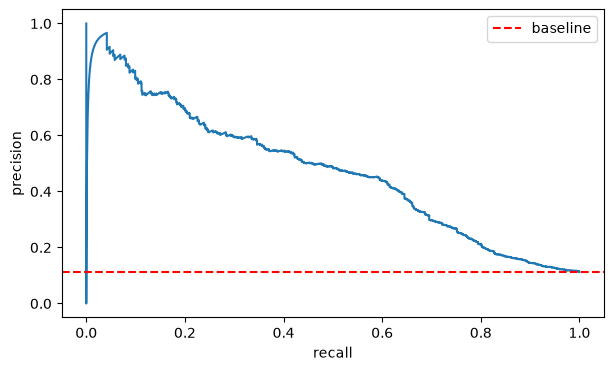

In [59]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, val_proba)

plt.figure(figsize=(7, 4))
plt.plot(recall, precision)
plt.axhline(y_val.mean(), color='red', linestyle='--', label='baseline')
plt.xlabel('recall')
plt.ylabel('precision')
plt.legend()
plt.show()

In [60]:
for t in [0.2, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7]:
    pred = (val_proba >= t).astype(int)
    tp = ((y_val == 1) & (pred == 1)).sum()
    fp = ((y_val == 0) & (pred == 1)).sum()
    fn = ((y_val == 1) & (pred == 0)).sum()

    prec = tp / (tp + fp)
    rec = tp / (tp + fn)
    f1 = 2 * prec * rec / (prec + rec)
    calls = tp + fp

    print(f"t={t:.2f}  calls {calls:>5,}  precision {prec:.3f}  "
          f"recall {rec:.3f}  F1 {f1:.3f}")

t=0.20  calls 4,789  precision 0.134  recall 0.924  F1 0.234
t=0.30  calls 3,008  precision 0.189  recall 0.818  F1 0.307
t=0.35  calls 2,249  precision 0.239  recall 0.772  F1 0.365
t=0.40  calls 1,695  precision 0.291  recall 0.708  F1 0.412
t=0.50  calls 1,177  precision 0.381  recall 0.645  F1 0.479
t=0.60  calls   944  precision 0.440  recall 0.596  F1 0.506
t=0.70  calls   768  precision 0.474  recall 0.523  F1 0.497


In [61]:
X_test_tree = tree_prep.transform(X_test)

In [62]:
test_proba = xgb_hp.predict_proba(X_test_tree)[:, 1]

print(f"PR-AUC  test: {average_precision_score(y_test, test_proba):.4f}")
print(f"ROC-AUC test: {roc_auc_score(y_test, test_proba):.4f}")

test_pred = (test_proba >= 0.5).astype(int)
tp = ((y_test == 1) & (test_pred == 1)).sum()
fp = ((y_test == 0) & (test_pred == 1)).sum()
fn = ((y_test == 1) & (test_pred == 0)).sum()

print(f"\nAt threshold 0.5:")
print(f"calls: {tp + fp:,}")
print(f"precision: {tp / (tp + fp):.3f}")
print(f"recall: {tp / (tp + fn):.3f}")

PR-AUC  test: 0.4896
ROC-AUC test: 0.8159

At threshold 0.5:
calls: 1,092
precision: 0.410
recall: 0.644


## Final result

Best model: XGBoost tuned with Hyperopt, evaluated once on the held-out test set.

| Metric | Validation | Test |
|---|---|---|
| PR-AUC | 0.4735 | 0.4896 |
| ROC-AUC | 0.8024 | 0.8159 |
| Precision @0.5 | 0.381 | 0.410 |
| Recall @0.5 | 0.645 | 0.644 |

Test slightly exceeds validation, which indicates the model was not overfitted to the
validation set during selection. The gap (+0.016) is within the variation expected
between two samples of ~6,000 rows.

**In operational terms.** Out of 6,177 clients, the model recommends 1,092 calls — 18%
of the base. Those calls capture 64.4% of all subscribers at 41.0% conversion, against
an 11.3% baseline. The call centre would reach roughly two thirds of potential
subscribers while making under a fifth of the calls, with nearly four in ten calls
converting instead of one in nine.